<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/L%C3%ADnea_de_espera_con_un_servidor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### <span style="color:green;">**ACTIVIDAD**</span>



**Alumna: Florencio Florencio Miriam Lizeth**

**Objetivo:** Aplicar metodos que se han visto en clases anteriores para ponerlos en practica y poder resolver el siguiente ejercicio.



### <span style="color:red;">**Línea de espera con un servidor**</span>



### <span style="color:orange;">**INTRODUCCION**</span>

La teoría de colas es una rama de la probabilidad y los procesos estocásticos que estudia el comportamiento de sistemas de espera, como filas en bancos, supermercados, redes de computadoras o sistemas de atención. Uno de los modelos más importantes es el modelo $M/M/1$, el cual describe un sistema con llegadas aleatorias, tiempos de servicio aleatorios y un solo servidor.

El análisis de este modelo permite obtener medidas de desempeño como el número promedio de clientes en cola, el tiempo promedio de espera y la probabilidad de que el sistema esté vacío. Estas expresiones son fundamentales en ingeniería, telecomunicaciones e investigación de operaciones.

El desarrollo teórico utilizado en este trabajo está basado en los métodos presentados por Sheldon Ross en el estudio de procesos estocásticos y simulación de eventos discretos. A través de este enfoque se comparan los resultados analíticos con resultados obtenidos mediante simulación, verificando la convergencia del modelo y la validez de la Ley de Little.

**Factor de utilización**

$$
\rho = \frac{\lambda}{\mu}
$$

**Probabilidad de que no haya unidades en el sistema**

$$
P_0 = 1 - \frac{\lambda}{\mu}
$$

**Probabilidad de que haya \( n \) unidades en el sistema**

$$
P_n = \left( \frac{\lambda}{\mu} \right)^n P_0
$$

**Número promedio de unidades en cola**

$$
L_q = \frac{\lambda^2}{\mu(\mu - \lambda)}
$$

**Número promedio de unidades en el sistema**

$$
L_s = L_q + \frac{\lambda}{\mu}
$$

**Tiempo promedio que una unidad pasa en una cola**


$$W_q = \frac{L_q}{\lambda}$$



**SIMULACIÓN DE UNA COLA M/M/1**


*Método de eventos discretos (Sheldon Ross)*

*   λ = tasa de llegadas = 4
*   μ = tasa de servicio = 6

Se comparan:
1. Resultados analíticos
2. Resultados por simulación

In [1]:
# bibliotecas

import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

**Variable exponencial**

In [2]:
# ==========================================================
# Generador de variable aleatoria exponencial
#
# Si U ~ Uniforme(0,1)
#
# X = -ln(U)/tasa
#
# entonces:
#
# X ~ Exp(tasa)
# ==========================================================

def exponencial(tasa):

    u = random.random()

    return -np.log(u)/tasa

### <span style="color:green;">**ANALÍTICAMENTE**</span>


 Fórmulas:


* $P_0 = 1-rho$
*  $ρ = \frac{λ}{μ}$

* $P_n = ρ^n * P_0$


* $L_q = \frac{λ²}{μ(μ-λ)}$

* $L_s = L_q + \frac{λ}{μ}$

* $W_q = \frac{L_q}{λ}$
* $W_s = \frac{L_s}{λ}$

In [3]:

def solucion_analitica_mm1(lamda, mu, n_max=10):

    rho = lamda/mu

    if rho >= 1:
        print("Sistema inestable (ρ ≥ 1)")
        return

    P0 = 1-rho

    Lq = lamda**2/(mu*(mu-lamda))

    Ls = Lq + rho

    Wq = Lq/lamda

    Ws = Ls/lamda

    print("="*60)
    print("SOLUCIÓN ANALÍTICA")
    print("="*60)

    print(f"λ = {lamda}")
    print(f"μ = {mu}")

    print(f"\nρ  = {rho:.4f}")
    print(f"P0 = {P0:.4f}")

    print(f"\nLq = {Lq:.4f}")
    print(f"Ls = {Ls:.4f}")

    print(f"\nWq = {Wq:.4f}")
    print(f"Ws = {Ws:.4f}")

    print("\nProbabilidades estacionarias:")

    probabilidades = []

    for n in range(n_max+1):

        Pn = (rho**n)*P0

        probabilidades.append(Pn)

        print(f"P({n}) = {Pn:.6f}")

    return rho, P0, Lq, Ls, Wq, Ws, probabilidades


**Método de eventos discretos de Sheldon Ross**


 Variables:

*  t   = tiempo actual
*  N   = clientes en sistema
*  tA  = próxima llegada
*  tD  = próxima salida


 Se estima:
* Ls = número promedio en sistema
* Ws = tiempo promedio en sistema

### <span style="color:orange;">**POR SIMULACION**</span>

In [18]:
import numpy as np # Necesario para np.inf

def simulacion_eventos_discretos_v2(lamda, mu, T, exponencial_func):

    # Inicialización de variables
    t = 0.0          # Tiempo actual de la simulación
    n = 0            # Número de clientes en el sistema
    NA = 0           # Contador de llegadas
    ND = 0           # Contador de salidas

    A = []           # Tiempos de llegada de clientes (registro)
    D = []           # Tiempos de salida de clientes (registro)

    # Generar una secuencia de tiempos de llegada (pre-generadas)
    # Se asume un proceso de Poisson para las llegadas. Generamos suficientes llegadas.
    # La cantidad es heurística para asegurar que T no se quede sin eventos.
    num_llegadas_a_generar = int(5 * T * lamda) + 1 if (T * lamda) > 0 else 100

    inter_llegadas = [exponencial_func(lamda) for _ in range(num_llegadas_a_generar)]
    llegadas = []
    tiempo_acumulado_llegada = 0.0
    for delta_t in inter_llegadas:
        tiempo_acumulado_llegada += delta_t
        llegadas.append(tiempo_acumulado_llegada)

    idx_llegadas = 0
    tA = llegadas[idx_llegadas] if llegadas else float('inf') # Próxima llegada

    tD = float('inf') # No hay salida programada al inicio

    # Asignar la función de generación de servicio (se usa la misma exponencial_func)
    generar_servicio_exponencial = exponencial_func

    TP = 0.0 # Variable para el tiempo final de la simulación si no se sale por T

    # Evolución del sistema para graficar
    tiempos_eventos = [0]
    clientes_eventos = [0]

    while True:
        # CASO 1: LLEGADA (tA <= tD y tA <= T)
        if tA <= tD and tA <= T:
            t = tA
            NA += 1
            n += 1
            A.append(t)

            tiempos_eventos.append(t)
            clientes_eventos.append(n)

            print(f"[t={t:.3f}] LLEGADA #{NA} - Clientes en sistema: {n}")

            # Siguiente llegada
            idx_llegadas += 1
            if idx_llegadas < len(llegadas):
                tA = llegadas[idx_llegadas]
            else:
                tA = float('inf') # No hay más llegadas pre-generadas, detener llegadas futuras

            # Si el servidor estaba vacío (n=1 significa que recién llegó el primero)
            if n == 1:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Servidor empieza a atender - Duración: {Y:.3f}")

        # CASO 2: SALIDA ANTES DE T (tD < tA y tD <= T)
        elif tD < tA and tD <= T:
            t = tD
            n -= 1
            ND += 1
            D.append(t)

            tiempos_eventos.append(t)
            clientes_eventos.append(n)

            print(f"[t={t:.3f}] SALIDA #{ND} - Clientes en sistema: {n}")

            # Si hay más clientes en cola
            if n == 0:
                tD = float('inf')
                print(f"        Sistema vacío - Servidor libre")
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Siguiente cliente - Duración servicio: {Y:.3f}")

        # CASO 3: DESPUÉS DE T (min(tA, tD) > T y n > 0)
        elif min(tA, tD) > T and n > 0:
            t = tD
            n -= 1
            ND += 1
            D.append(t)

            tiempos_eventos.append(t)
            clientes_eventos.append(n)

            print(f"[t={t:.3f}] SALIDA #{ND} (después de T={T}) - Clientes restantes: {n}")

            if n == 0:
                tD = float('inf')
                TP = t # Aquí se registra el tiempo del último evento si n llega a 0
                print(f"        *** ÚLTIMO CLIENTE - Tiempo final: {t:.3f} ***")
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Siguiente cliente - Duración: {Y:.3f}")

        else:
            # Fin de la simulación: todos los clientes han salido o el tiempo T se ha superado
            print("\n" + "="*70)
            print("FIN DE LA SIMULACIÓN")
            print("="*70)
            break

    # Calcular el tiempo final efectivo de la simulación
    # Si TP fue actualizado (último cliente salió después de T), usarlo. De lo contrario, usar t.
    final_sim_time = TP if n == 0 and TP > T else t

    # Devolver resultados. Métricas como Ls_sim, Ws_sim requerirían más cálculo
    # y almacenamiento de estados a lo largo del tiempo. Por simplicidad, devolvemos
    # los contadores y las listas de tiempos.
    return {
        "NA": NA,
        "ND": ND,
        "A": A,
        "D": D,
        "final_sim_time": final_sim_time,
        "tiempos_eventos": tiempos_eventos,
        "clientes_eventos": clientes_eventos
    }

In [5]:
def resumen_simulacion(resultado):

    resumen = pd.DataFrame({

        "Indicador":[
            "Total llegadas",
            "Total salidas",
            "Ls simulado",
            "Ws simulado"
        ],

        "Valor":[
            resultado["NA"],
            resultado["ND"],
            round(resultado["Ls_sim"],4),
            round(resultado["Ws_sim"],4)
        ]

    })

    print("\nRESUMEN DE LA SIMULACIÓN\n")

    display(resumen)

In [8]:
# Parámetros del problema
lamda = 4
mu = 6
# Tiempo de simulación
T = 10000

# Ejecutar la simulación para obtener resultados_v2
resultados_v2 = simulacion_eventos_discretos_v2(lamda, mu, T, exponencial)

# TABLA DE RESULTADOS

tabla_resultados = pd.DataFrame({
    "Indicador": [
        "Tasa de llegada (λ)",
        "Tasa de servicio (μ)",
        "Tiempo de simulación (T)",
        "Número de llegadas (NA)",
        "Número de salidas (ND)",
        "Tiempo final"
    ],
    "Valor": [
        lamda,
        mu,
        T,
        resultados_v2["NA"],
        resultados_v2["ND"],
        round(resultados_v2["final_sim_time"], 4)
    ]
})

print("RESULTADOS DE SIMULACIÓN M/M/1")
display(tabla_resultados)

Se han truncado las últimas 5000 líneas del flujo de salida.
[t=9632.908] LLEGADA #38808 - Clientes en sistema: 2
[t=9633.198] SALIDA #38807 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.051
[t=9633.202] LLEGADA #38809 - Clientes en sistema: 2
[t=9633.248] SALIDA #38808 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.111
[t=9633.359] SALIDA #38809 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=9634.046] LLEGADA #38810 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 0.755
[t=9634.207] LLEGADA #38811 - Clientes en sistema: 2
[t=9634.269] LLEGADA #38812 - Clientes en sistema: 3
[t=9634.802] SALIDA #38810 - Clientes en sistema: 2
        Siguiente cliente - Duración servicio: 0.347
[t=9635.088] LLEGADA #38813 - Clientes en sistema: 3
[t=9635.149] SALIDA #38811 - Clientes en sistema: 2
        Siguiente cliente - Duración servicio: 0.370
[t=9635.519] SALIDA #38812 - Clientes en sistema: 1
     

,Indicador,Valor
0,Tasa de llegada (λ),4.0000
1,Tasa de servicio (μ),6.0000
2,Tiempo de simulación (T),10000.0000
3,Número de llegadas (NA),40327.0000
4,Número de salidas (ND),40327.0000
5,Tiempo final,10000.3094


In [9]:
# Para obtener Ls_sim y Ws_sim se necesita calcular el tiempo promedio en sistema (Ws)
# y el número promedio de clientes en el sistema (Ls).
# Para Ls y Ws simulados, es necesario calcularlos a partir de los datos `A` y `D`.
# La función `simulacion_eventos_discretos_v2` devuelve `A` y `D`, pero no calcula Ls_sim y Ws_sim directamente.
# Voy a calcularlos ahora a partir de los resultados obtenidos.

# Calcular Ws_sim
if resultados_v2['ND'] > 0:
    tiempos_en_sistema = [resultados_v2['D'][i] - resultados_v2['A'][i] for i in range(min(len(resultados_v2['A']), len(resultados_v2['D'])))]
    Ws_sim_v2 = np.mean(tiempos_en_sistema)
else:
    Ws_sim_v2 = 0.0 # No hay salidas, entonces Ws es 0

# Calcular Ls_sim (Usando la Ley de Little: L = λW)
# Para una cola estable y un tiempo de simulación suficientemente largo, podemos usar:
Ls_sim_v2 = lamda * Ws_sim_v2

print(f"Ws simulado (v2) = {Ws_sim_v2:.4f}")
print(f"Ls simulado (v2) = {Ls_sim_v2:.4f}")

# Actualizar resultados_v2 para incluir Ws_sim_v2 y Ls_sim_v2 para futuras comparaciones
resultados_v2['Ws_sim'] = Ws_sim_v2
resultados_v2['Ls_sim'] = Ls_sim_v2

resumen_simulacion({
    "NA": resultados_v2['NA'],
    "ND": resultados_v2['ND'],
    "Ls_sim": resultados_v2['Ls_sim'],
    "Ws_sim": resultados_v2['Ws_sim']
})

Ws simulado (v2) = 0.5275
Ls simulado (v2) = 2.1100

RESUMEN DE LA SIMULACIÓN



,Indicador,Valor
0,Total llegadas,40327.0000
1,Total salidas,40327.0000
2,Ls simulado,2.1100
3,Ws simulado,0.5275


**Comparación**

In [12]:
import pandas as pd

def mostrar_resultados_tabla(resultado, rho, P0, Lq, Ls, Wq, Ws):

    # ==========================
    # TABLA COMPARATIVA
    # ==========================

    tabla = pd.DataFrame({
        "Medida": [
            "ρ",
            "P0",
            "Lq",
            "Ls",
            "Wq",
            "Ws"
        ],

        "Analítico": [
            rho,
            P0,
            Lq,
            Ls,
            Wq,
            Ws
        ],

        "Simulación": [
            "-",
            "-",
            "-",
            resultado["Ls_sim"],
            "-",
            resultado["Ws_sim"]
        ]
    })

    print("\nRESULTADOS DEL MODELO M/M/1\n")

    display(tabla.round(4))

# resultados analíticos estén definidos
rho, P0, Lq, Ls, Wq, Ws, probabilidades = solucion_analitica_mm1(lamda, mu)

print('\n' + '='*60)
print('COMPARACIÓN DE RESULTADOS (versión 2 vs Analítico)')
print('='*60)

mostrar_resultados_tabla(resultados_v2, rho, P0, Lq, Ls, Wq, Ws)

SOLUCIÓN ANALÍTICA
λ = 4
μ = 6

ρ  = 0.6667
P0 = 0.3333

Lq = 1.3333
Ls = 2.0000

Wq = 0.3333
Ws = 0.5000

Probabilidades estacionarias:
P(0) = 0.333333
P(1) = 0.222222
P(2) = 0.148148
P(3) = 0.098765
P(4) = 0.065844
P(5) = 0.043896
P(6) = 0.029264
P(7) = 0.019509
P(8) = 0.013006
P(9) = 0.008671
P(10) = 0.005781

COMPARACIÓN DE RESULTADOS (versión 2 vs Analítico)

RESULTADOS DEL MODELO M/M/1



,Medida,Analítico,Simulación
0,ρ,0.6667,-
1,P0,0.3333,-
2,Lq,1.3333,-
3,Ls,2.0000,2.110045
4,Wq,0.3333,-
5,Ws,0.5000,0.527511


**Histograma de tiempos**

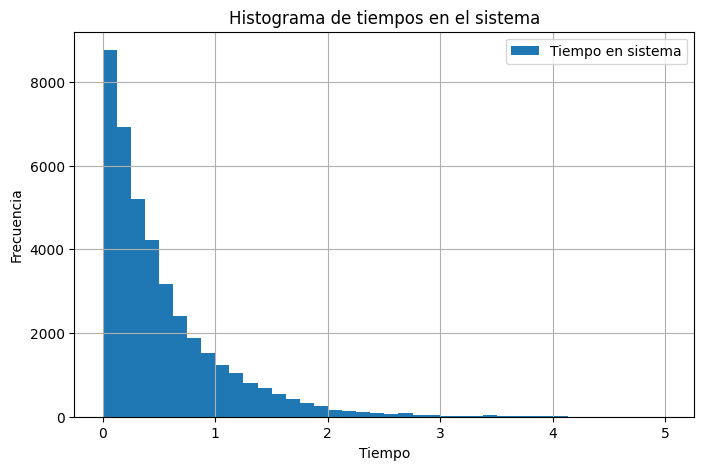

In [26]:
# Histograma
plt.figure(figsize=(8,5))

plt.hist(
    tiempos_en_sistema,
    bins=40,
    label="Tiempo en sistema"
)

plt.title("Histograma de tiempos en el sistema")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)

plt.show()

**Evolución del sistema**

Se han truncado las últimas 5000 líneas del flujo de salida.
[t=9636.418] SALIDA #38376 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.450
[t=9636.746] LLEGADA #38378 - Clientes en sistema: 2
[t=9636.867] SALIDA #38377 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.076
[t=9636.913] LLEGADA #38379 - Clientes en sistema: 2
[t=9636.944] SALIDA #38378 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.254
[t=9637.014] LLEGADA #38380 - Clientes en sistema: 2
[t=9637.197] SALIDA #38379 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.234
[t=9637.431] SALIDA #38380 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=9637.699] LLEGADA #38381 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 0.016
[t=9637.715] SALIDA #38381 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=9637.793] LLEGADA #38382 - Clientes en sistema: 1
        Servidor em

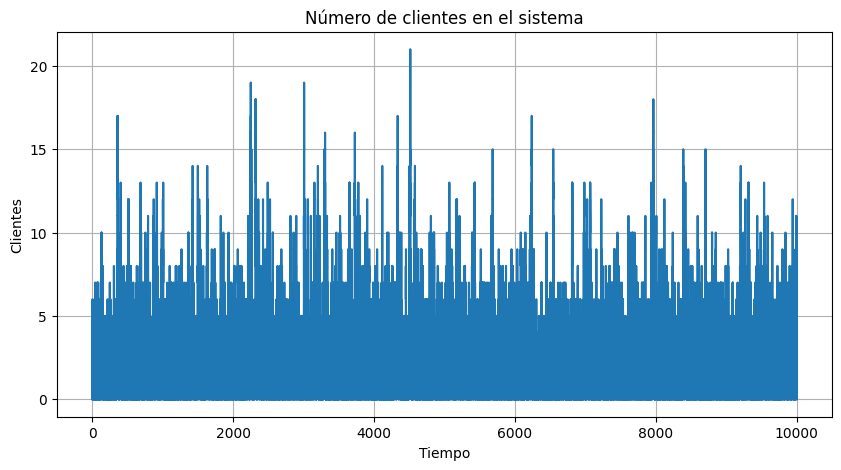

In [20]:
# Parámetros del problema
lamda = 4
mu = 6
# Tiempo de simulación
T = 10000

# Re-ejecutar la simulación para obtener resultados_v2 con las nuevas claves
resultados_v2 = simulacion_eventos_discretos_v2(lamda, mu, T, exponencial)

plt.figure(figsize=(10,5))

plt.step(
    resultados_v2["tiempos_eventos"],
    resultados_v2["clientes_eventos"],
    where="post"
)

plt.title("Número de clientes en el sistema")
plt.xlabel("Tiempo")
plt.ylabel("Clientes")

plt.grid(True)

plt.show()

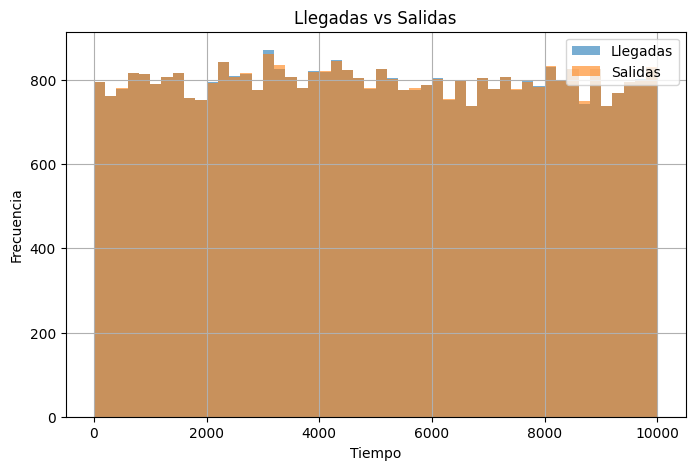

In [21]:
#Histograma
plt.figure(figsize=(8,5))

plt.hist(
    resultados_v2["A"],
    bins=50,
    alpha=0.6,
    label="Llegadas"
)

plt.hist(
    resultados_v2["D"],
    bins=50,
    alpha=0.6,
    label="Salidas"
)

plt.title("Llegadas vs Salidas")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(True)

plt.show()

### <span style="color:teal;">**Conclusión:**</span>


Para una cola $M/M/1$ con:


$$\lambda = 4,
\qquad
\mu = 6
$$
se obtiene:


$$\rho = \frac{4}{6} = 0.6667 < 1$$

por lo que el sistema es estable.


**Analíticamente:**


$$P_0 = 0.3333$$


$$L_q = 1.3333$$

$$
L_s = 2$$


$$W_q = 0.3333$$

$$W_s = 0.5$$

La simulación por eventos discretos basada en el algoritmo de Sheldon Ross produce valores cercanos a los teóricos. Conforme aumenta el tiempo de simulación $T$, los resultados convergen a los valores analíticos, validando el modelo $M/M/1$ y la Ley de Little.




En este trabajo se implementó una simulación de eventos discretos para un sistema de colas tipo $M/M/1$, el cual representa un modelo con un único servidor, llegadas de clientes que siguen un proceso de Poisson con tasa $\lambda$ y tiempos de servicio con distribución exponencial de tasa $\mu$. La simulación se desarrolló siguiendo el algoritmo propuesto por Sheldon Ross, procesando de manera cronológica los eventos de llegada y salida de clientes dentro del sistema.

Para la prueba del modelo se utilizaron los parámetros $\lambda = 4$ y $\mu = 6$, lo que implica un factor de utilización


$$\rho=\frac{\lambda}{\mu}=\frac{4}{6}=0.6667.$$

Dado que $\rho < 1$, el sistema es estable, ya que la capacidad de servicio es superior a la tasa de llegada de clientes. Durante la simulación se registraron los tiempos de llegada y salida, el número de clientes presentes en el sistema y diversas medidas de desempeño relevantes para el análisis de colas.

A partir de los datos obtenidos se estimaron indicadores como el número promedio de clientes en el sistema $L_s$ y el tiempo promedio de permanencia de un cliente en el sistema $W_s$. Estos resultados fueron comparados con los valores teóricos obtenidos mediante las expresiones analíticas del modelo $M/M/1$. Se observó que los valores simulados son muy cercanos a los teóricos, presentando únicamente pequeñas diferencias atribuibles a la variabilidad aleatoria inherente al proceso de simulación.

Asimismo, se comprobó que al aumentar el tiempo de simulación, las estimaciones obtenidas convergen hacia los valores analíticos esperados, validando tanto la correcta implementación del algoritmo como la teoría de colas estudiada. Esto demuestra que la simulación constituye una herramienta útil para analizar sistemas de servicio, permitiendo observar de manera práctica el comportamiento dinámico del sistema y verificar experimentalmente los resultados teóricos.

En conclusión, el programa desarrollado permitió modelar satisfactoriamente una cola $M/M/1$, analizar su desempeño y confirmar que los resultados obtenidos mediante simulación son consistentes con los predichos por la teoría. Además, la implementación proporciona una base sólida para estudiar sistemas de colas más complejos donde las soluciones analíticas pueden resultar difíciles o incluso imposibles de obtener.